In [6]:
import fabio
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import time

start = time.time()
# -------------------------------
# Paths
# -------------------------------
input_folder = "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/60/Ta2NiSeS70_029"
output_folder = "/nfs/chess/user/aa2994/example2"

# Validate input folder exists
if not os.path.exists(input_folder):
    print(f"ERROR: Input folder does not exist: {input_folder}")
    sys.exit(1)

# Create output folder
try:
    os.makedirs(output_folder, exist_ok=True)
    print(f"Output folder ready: {output_folder}")
except Exception as e:
    print(f"ERROR: Cannot create output folder: {e}")
    sys.exit(1)

# -------------------------------
# Load and sum files (optimized)
# -------------------------------
try:
    all_files = os.listdir(input_folder)
    cbf_files = sorted([f for f in all_files if f.endswith(".cbf")])[:15]
    print(f"Found {len([f for f in all_files if f.endswith('.cbf')])} CBF files, processing first {len(cbf_files)}")
except Exception as e:
    print(f"ERROR: Cannot read input folder: {e}")
    sys.exit(1)

if len(cbf_files) == 0:
    print("ERROR: No CBF files found!")
    print(f"Files in directory: {all_files[:2]}")  # Show first 10 files for debugging
    sys.exit(1)

print(f"Processing {len(cbf_files)} CBF files...")

sum_image = None
successful_files = 0
failed_files = []

for i, file in enumerate(cbf_files):
    try:
        file_path = os.path.join(input_folder, file)
        if not os.path.exists(file_path):
            print(f"Warning: File does not exist: {file}")
            failed_files.append(file)
            continue
            
        data = fabio.open(file_path).data
        
        if sum_image is None:
            sum_image = data.astype(np.float32)
        else:
            sum_image += data
            
        successful_files += 1
        
        if (i + 1) % 5 == 0:
            print(f"Processed {i + 1}/{len(cbf_files)} files ({successful_files} successful)")
            
    except Exception as e:
        print(f"Error with {file}: {e}")
        failed_files.append(file)

if sum_image is None:
    print("ERROR: No valid data loaded!")
    print(f"Failed files: {failed_files}")
    sys.exit(1)

print(f"Sum complete: {sum_image.shape}, range [{sum_image.min():.1f}, {sum_image.max():.1f}]")
print(f"Successfully processed {successful_files}/{len(cbf_files)} files")

if failed_files:
    print(f"Failed files ({len(failed_files)}): {failed_files}")

# Remove negatives
negative_count = np.sum(sum_image < 0)
if negative_count > 0:
    print(f"Removing {negative_count:,} negative pixels")
    sum_image = np.maximum(sum_image, 0)

# -------------------------------
# Log method only
# -------------------------------
print("Applying logarithmic transformation...")
log_img = np.log1p(sum_image)  # log(1 + x) to handle zeros
#log_img = 5**log_img
#vmin, vmax = np.percentile(log_img, [5, 99.5]) #seems arbitrary??
vmin, vmax = np.percentile(log_img, [1, 99.9])
log_processed = np.clip((log_img - vmin) / (vmax - vmin), 0, 1)

print(f"Log transform: original range [{sum_image.min():.1f}, {sum_image.max():.1f}] "
      f"→ log range [{log_img.min():.3f}, {log_img.max():.3f}] "
      f"→ normalized [{log_processed.min():.3f}, {log_processed.max():.3f}]")

# -------------------------------
# Visualization
# -------------------------------
print("Creating visualization...")
try:
    plt.figure(figsize=(10, 8))
    im = plt.imshow(log_processed, cmap='gist_ncar', origin='lower')
    plt.title(f'Log Transform Method\n{successful_files} CBF files summed', fontsize=14)
    plt.colorbar(im, label='Normalized Log Intensity')
    plt.xlabel('Detector X (pixels)')
    plt.ylabel('Detector Y (pixels)')
    
    # Add some statistics to the plot
    plt.figtext(0.02, 0.02, 
                f'Original range: [{sum_image.min():.0f}, {sum_image.max():.0f}]\n'
                f'Dynamic range: {np.log10(sum_image.max() / np.maximum(sum_image[sum_image > 0].min(), 1)):.1f} decades',
                fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    output_plot = os.path.join(output_folder, "log_method2.png")
    plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Plot saved to: {output_plot}")
    
    # Show plot (comment out if running on headless system)
    # plt.show()
    plt.close()
    
except Exception as e:
    print(f"Warning: Could not create plot: {e}")

# Save raw data
try:
    raw_output = os.path.join(output_folder, "summed_raw.npy")
    np.save(raw_output, sum_image)
    print(f"Raw data saved to: {raw_output}")
except Exception as e:
    print(f"Warning: Could not save raw data: {e}")

# -------------------------------
# Calculate all statistics
# -------------------------------
print("Calculating comprehensive statistics...")

# Basic stats
shape = sum_image.shape
total_pixels = sum_image.size
min_val = sum_image.min()
max_val = sum_image.max()
mean_val = sum_image.mean()
median_val = np.median(sum_image)
std_val = sum_image.std()

# Data distribution
nonzero_count = np.count_nonzero(sum_image)
zero_count = sum_image.size - nonzero_count
nonzero_percent = 100 * nonzero_count / sum_image.size
zero_percent = 100 * zero_count / sum_image.size
unique_values = len(np.unique(sum_image))

# Percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5]
perc_values = np.percentile(sum_image, percentiles)

# Dynamic range and intensity analysis
dynamic_range = max_val / np.maximum(min_val, 1)
positive_data = sum_image[sum_image > 0]
log_dynamic_range = np.log10(max_val / np.maximum(positive_data.min(), 1)) if len(positive_data) > 0 else 0
snr = mean_val / np.maximum(std_val, 1e-10)
coeff_variation = std_val / np.maximum(mean_val, 1e-10)

# Hot pixels and outliers
threshold_99_9 = np.percentile(sum_image, 99.9)
hot_pixels = np.sum(sum_image > threshold_99_9)
hot_pixels_percent = 100 * hot_pixels / sum_image.size
outliers_3sigma = np.sum(sum_image > mean_val + 3 * std_val)

# Memory usage
memory_mb = sum_image.nbytes / (1024**2)

# Non-zero data statistics
if len(positive_data) > 0:
    nonzero_min = positive_data.min()
    nonzero_mean = positive_data.mean()
    nonzero_std = positive_data.std()
else:
    nonzero_min = nonzero_mean = nonzero_std = 0

# Image quality metrics
total_intensity = sum_image.sum()
avg_intensity_per_file = total_intensity / successful_files

# Calculate entropy more safely
sum_image_safe = sum_image + 1e-10  # Avoid log(0)
sum_image_norm = sum_image_safe / sum_image_safe.sum()  # Normalize for proper entropy
entropy = -np.sum(sum_image_norm * np.log(sum_image_norm))

# Log processed statistics
log_min = log_processed.min()
log_max = log_processed.max()
log_mean = log_processed.mean()
log_std = log_processed.std()

print(f"Statistics calculated - Dynamic range: {log_dynamic_range:.2f} decades, "
      f"SNR: {snr:.1f}, Non-zero pixels: {nonzero_percent:.1f}%")

# -------------------------------
# Write comprehensive statistics to text file
# -------------------------------
stats_file = os.path.join(output_folder, "image_statistics_report2.txt")

try:
    with open(stats_file, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("IMAGE STATISTICS REPORT - DETAILED ANALYSIS\n")
        f.write("=" * 80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Input folder: {input_folder}\n")
        f.write(f"Files processed successfully: {successful_files}/{len(cbf_files)}\n")
        if failed_files:
            f.write(f"Failed files: {len(failed_files)}\n")
        f.write("=" * 80 + "\n\n")
        
        # BASIC IMAGE PROPERTIES
        f.write("1. BASIC IMAGE PROPERTIES\n")
        f.write("-" * 40 + "\n")
        f.write(f"Shape: {shape}\n")
        f.write("  → Image dimensions in pixels (height × width)\n\n")
        
        f.write(f"Total pixels: {total_pixels:,}\n")
        f.write("  → Total number of detector pixels\n\n")
        
        f.write(f"Data type: {sum_image.dtype}\n")
        f.write("  → Memory format used to store pixel values\n\n")
        
        f.write(f"Memory usage: {memory_mb:.1f} MB\n")
        f.write("  → RAM required to store this image\n\n")
        
        # INTENSITY STATISTICS
        f.write("2. INTENSITY STATISTICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Minimum value: {min_val:.3f}\n")
        f.write("  → Lowest intensity recorded (background level after negative removal)\n\n")
        
        f.write(f"Maximum value: {max_val:.3f}\n")
        f.write("  → Highest intensity recorded (brightest diffraction spot)\n\n")
        
        f.write(f"Mean value: {mean_val:.3f}\n")
        f.write("  → Average intensity across all pixels\n\n")
        
        f.write(f"Median value: {median_val:.3f}\n")
        f.write("  → Middle value when all pixels are sorted by intensity\n")
        f.write("  → Less affected by extreme outliers than mean\n\n")
        
        f.write(f"Standard deviation: {std_val:.3f}\n")
        f.write("  → Measure of intensity variation across the image\n")
        f.write("  → High values indicate more contrast/dynamic range\n\n")
        
        # DATA DISTRIBUTION
        f.write("3. DATA DISTRIBUTION ANALYSIS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Non-zero pixels: {nonzero_count:,} ({nonzero_percent:.1f}%)\n")
        f.write("  → Pixels with actual signal above zero\n")
        f.write("  → Higher percentages indicate more diffraction coverage\n\n")
        
        f.write(f"Zero pixels: {zero_count:,} ({zero_percent:.1f}%)\n")
        f.write("  → Background/empty regions of detector\n\n")
        
        f.write(f"Unique intensity values: {unique_values:,}\n")
        f.write("  → Number of distinct intensity levels in the image\n")
        f.write("  → Higher values indicate better intensity resolution\n\n")
        
        # PERCENTILE ANALYSIS
        f.write("4. PERCENTILE ANALYSIS\n")
        f.write("-" * 40 + "\n")
        f.write("Intensity distribution breakdown:\n")
        for p, v in zip(percentiles, perc_values):
            f.write(f"  {p:3f}th percentile: {v:.3f}\n")
        f.write("\nExplanation:\n")
        f.write("  → Shows how intensities are distributed across the image\n")
        f.write("  → 50th percentile = median\n")
        f.write("  → 99th percentile shows where the brightest 1% of pixels start\n")
        f.write("  → Large gaps between percentiles indicate intensity clustering\n\n")
        
        # DYNAMIC RANGE
        f.write("5. DYNAMIC RANGE ANALYSIS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Linear dynamic range: {dynamic_range:.1f}\n")
        f.write("  → Ratio of brightest to dimmest pixel (max/min)\n")
        f.write("  → Higher values mean more contrast in the image\n\n")
        
        f.write(f"Logarithmic dynamic range: {log_dynamic_range:.2f} decades\n")
        f.write("  → Dynamic range expressed in orders of magnitude\n")
        f.write("  → >3 decades indicates high dynamic range requiring log scaling\n")
        f.write("  → <1 decade suggests low contrast image\n\n")
        
        # SIGNAL QUALITY
        f.write("6. SIGNAL QUALITY METRICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Signal-to-noise ratio: {snr:.2f}\n")
        f.write("  → Mean intensity divided by standard deviation\n")
        f.write("  → Higher values indicate cleaner, less noisy data\n")
        f.write("  → Values >10 are generally considered good\n\n")
        
        f.write(f"Coefficient of variation: {coeff_variation:.3f}\n")
        f.write("  → Normalized measure of intensity variation (std/mean)\n")
        f.write("  → Lower values indicate more uniform intensity distribution\n")
        f.write("  → Higher values indicate more contrast\n\n")
        
        # OUTLIER DETECTION
        f.write("7. OUTLIER AND HOT PIXEL ANALYSIS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Hot pixels (>99.9th percentile): {hot_pixels:,} ({hot_pixels_percent:.3f}%)\n")
        f.write("  → Extremely bright pixels that may be detector artifacts\n")
        f.write("  → Values >0.1% may indicate detector issues\n\n")
        
        f.write(f"Extreme outliers (>mean+3σ): {outliers_3sigma:,}\n")
        f.write("  → Pixels more than 3 standard deviations above mean\n")
        f.write("  → Statistical outliers that may need special handling\n\n")
        
        # NON-ZERO DATA ANALYSIS
        f.write("8. ACTIVE SIGNAL ANALYSIS (Positive pixels only)\n")
        f.write("-" * 40 + "\n")
        if len(positive_data) > 0:
            f.write(f"Minimum (positive): {nonzero_min:.3f}\n")
            f.write("  → Weakest detectable signal above background\n\n")
            
            f.write(f"Mean (positive): {nonzero_mean:.3f}\n")
            f.write("  → Average intensity of actual diffraction signals\n\n")
            
            f.write(f"Standard deviation (positive): {nonzero_std:.3f}\n")
            f.write("  → Variation within the active diffraction regions\n\n")
        else:
            f.write("No positive pixels found in the image.\n\n")
        
        # EXPERIMENT SUMMARY
        f.write("9. EXPERIMENT SUMMARY\n")
        f.write("-" * 40 + "\n")
        f.write(f"Total integrated intensity: {total_intensity:.0f}\n")
        f.write("  → Sum of all pixel intensities (total diffracted signal)\n\n")
        
        f.write(f"Average intensity per file: {avg_intensity_per_file:.0f}\n")
        f.write("  → Mean contribution from each input image\n\n")
        
        f.write(f"Information entropy: {entropy:.2e}\n")
        f.write("  → Measure of information content in the image\n")
        f.write("  → Higher values indicate more complex intensity patterns\n\n")
        
        # LOG PROCESSING RESULTS
        f.write("10. LOG-PROCESSED IMAGE STATISTICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Processed range: {log_min:.3f} to {log_max:.3f}\n")
        f.write("  → Intensity range after logarithmic transformation and normalization\n\n")
        
        f.write(f"Processed mean: {log_mean:.3f}\n")
        f.write("  → Average intensity in the display-optimized image\n\n")
        
        f.write(f"Processed std: {log_std:.3f}\n")
        f.write("  → Contrast level in the final processed image\n\n")
        
        # INTERPRETATION GUIDE
        f.write("11. INTERPRETATION GUIDE\n")
        f.write("-" * 40 + "\n")
        f.write("GOOD DIFFRACTION DATA INDICATORS:\n")
        f.write("• High non-zero pixel percentage (>10%)\n")
        f.write("• Log dynamic range > 2 decades\n")
        f.write("• Signal-to-noise ratio > 5\n")
        f.write("• Low hot pixel percentage (<0.01%)\n\n")
        
        f.write("POTENTIAL ISSUES TO CHECK:\n")
        f.write("• Very low non-zero percentage → weak diffraction\n")
        f.write("• Many hot pixels → detector problems\n")
        f.write("• Very high/low SNR → check exposure settings\n")
        f.write("• Low dynamic range → check sample/beam alignment\n\n")
        
        f.write("DATA PROCESSING RECOMMENDATIONS:\n")
        f.write(f"• Dynamic range: {log_dynamic_range:.1f} decades → ")
        if log_dynamic_range > 3:
            f.write("Use logarithmic scaling for visualization\n")
        elif log_dynamic_range > 1:
            f.write("Square root scaling may be sufficient\n")
        else:
            f.write("Linear scaling should work fine\n")
        
        f.write(f"• Hot pixels: {hot_pixels_percent:.3f}% → ")
        if hot_pixels_percent > 0.01:
            f.write("Consider hot pixel correction\n")
        else:
            f.write("Hot pixel levels are acceptable\n")
        
        # FILE PROCESSING SUMMARY
        if failed_files:
            f.write(f"\n12. PROCESSING ISSUES\n")
            f.write("-" * 40 + "\n")
            f.write(f"Failed to process {len(failed_files)} files:\n")
            for failed_file in failed_files:
                f.write(f"  • {failed_file}\n")
            f.write("\nRecommendation: Check file integrity and format\n")
        
        f.write("\n" + "=" * 80 + "\n")
        f.write("END OF REPORT\n")
        f.write("=" * 80 + "\n")
    
    print(f"✓ Detailed statistics saved to: {stats_file}")
    
except Exception as e:
    print(f"ERROR: Could not write statistics file: {e}")

print("✓ Log processing complete!")

# Print summary to console
print(f"\n{'='*60}")
print("PROCESSING SUMMARY")
print(f"{'='*60}")
print(f"Files processed: {successful_files}/{len(cbf_files)}")
print(f"Image shape: {shape}")
print(f"Intensity range: [{min_val:.0f}, {max_val:.0f}]")
print(f"Dynamic range: {log_dynamic_range:.1f} decades")
print(f"Non-zero pixels: {nonzero_percent:.1f}%")
print(f"Signal-to-noise: {snr:.1f}")
print(f"Output files saved to: {output_folder}")
print(f"{'='*60}")
end = time.time()
print(end-start)

Output folder ready: /nfs/chess/user/aa2994/example2
Found 3651 CBF files, processing first 15
Processing 15 CBF files...
Processed 5/15 files (5 successful)
Processed 10/15 files (10 successful)
Processed 15/15 files (15 successful)
Sum complete: (2527, 2463), range [-30.0, 835078.0]
Successfully processed 15/15 files
Removing 526,973 negative pixels
Applying logarithmic transformation...
Log transform: original range [0.0, 835078.0] → log range [0.000, 13.635] → normalized [0.000, 1.000]
Creating visualization...
Plot saved to: /nfs/chess/user/aa2994/example2/log_method2.png
Raw data saved to: /nfs/chess/user/aa2994/example2/summed_raw.npy
Calculating comprehensive statistics...
Statistics calculated - Dynamic range: 5.92 decades, SNR: 0.0, Non-zero pixels: 90.4%
✓ Detailed statistics saved to: /nfs/chess/user/aa2994/example2/image_statistics_report2.txt
✓ Log processing complete!

PROCESSING SUMMARY
Files processed: 15/15
Image shape: (2527, 2463)
Intensity range: [0, 835078]
Dynami

In [12]:
import fabio
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import time

start = time.time()
# -------------------------------
# Paths
# -------------------------------
input_folder = "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/60/Ta2NiSeS70_029"
output_folder = "/nfs/chess/user/aa2994/example3"

# Validate input folder exists
if not os.path.exists(input_folder):
    print(f"ERROR: Input folder does not exist: {input_folder}")
    sys.exit(1)

# Create output folder
try:
    os.makedirs(output_folder, exist_ok=True)
    print(f"Output folder ready: {output_folder}")
except Exception as e:
    print(f"ERROR: Cannot create output folder: {e}")
    sys.exit(1)

# -------------------------------
# Load and sum files (optimized)
# -------------------------------
try:
    all_files = os.listdir(input_folder)
    cbf_files = sorted([f for f in all_files if f.endswith(".cbf")])[:3]
    print(f"Found {len([f for f in all_files if f.endswith('.cbf')])} CBF files, processing first {len(cbf_files)}")
except Exception as e:
    print(f"ERROR: Cannot read input folder: {e}")
    sys.exit(1)

if len(cbf_files) == 0:
    print("ERROR: No CBF files found!")
    print(f"Files in directory: {all_files[:2]}")  # Show first files for debugging
    sys.exit(1)

print(f"Processing {len(cbf_files)} CBF files...")

sum_image = None
successful_files = 0
failed_files = []

# List to keep track of the first 3 valid image datasets for calculating difference images
first_three_images = []

for i, file in enumerate(cbf_files):
    try:
        file_path = os.path.join(input_folder, file)
        if not os.path.exists(file_path):
            print(f"Warning: File does not exist: {file}")
            failed_files.append(file)
            continue
            
        data = fabio.open(file_path).data
        
        # Save the first 3 valid images for difference imaging later
        if len(first_three_images) < 3:
            first_three_images.append((file, data.astype(np.float32)))
        
        if sum_image is None:
            sum_image = data.astype(np.float32)
        else:
            sum_image += data
            
        successful_files += 1
        
        if (i + 1) % 5 == 0:
            print(f"Processed {i + 1}/{len(cbf_files)} files ({successful_files} successful)")
            
    except Exception as e:
        print(f"Error with {file}: {e}")
        failed_files.append(file)

if sum_image is None:
    print("ERROR: No valid data loaded!")
    print(f"Failed files: {failed_files}")
    sys.exit(1)

print(f"Sum complete: {sum_image.shape}, range [{sum_image.min():.1f}, {sum_image.max():.1f}]")
print(f"Successfully processed {successful_files}/{len(cbf_files)} files")

if failed_files:
    print(f"Failed files ({len(failed_files)}): {failed_files}")

# Remove negatives
negative_count = np.sum(sum_image < 0)
if negative_count > 0:
    print(f"Removing {negative_count:,} negative pixels")
    sum_image = np.maximum(sum_image, 0)

# -------------------------------
# Log method only
# -------------------------------
print("Applying logarithmic transformation...")
#log_img = np.log1p(sum_image)  # log(1 + x) to handle zeros
#vmin, vmax = np.percentile(log_img, [1, 99.9])
#log_processed = np.clip((log_img - vmin) / (vmax - vmin), 0, 1)
log_processed = sum_image

print(f"Log transform: original range [{sum_image.min():.1f}, {sum_image.max():.1f}] "
      f"→ log range [{log_img.min():.3f}, {log_img.max():.3f}] "
      f"→ normalized [{log_processed.min():.3f}, {log_processed.max():.3f}]")
print(first_three_images)
# -------------------------------
# Visualization & Difference Images
# -------------------------------
print("Creating visualization...")
try:
    # 1. Core Plot: Save the primary log sum plot
    plt.figure(figsize=(10, 8))
    im = plt.imshow(log_processed, cmap='gist_ncar', origin='lower')
    plt.title(f'Log Transform Method\n{successful_files} CBF files summed', fontsize=14)
    plt.colorbar(im, label='Normalized Log Intensity')
    plt.xlabel('Detector X (pixels)')
    plt.ylabel('Detector Y (pixels)')
    
    plt.figtext(0.02, 0.02, 
                f'Original range: [{sum_image.min():.0f}, {sum_image.max():.0f}]\n'
                f'Dynamic range: {np.log10(sum_image.max() / np.maximum(sum_image[sum_image > 0].min(), 1)):.1f} decades',
                fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    output_plot = os.path.join(output_folder, "log_method2.png")
    plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Main plot saved to: {output_plot}")

    # 2. Difference Images Calculation and Visualization
    if len(first_three_images) >= 2:
        print(f"Calculating difference images for the first {len(first_three_images)} files...")
        
        # Calculate individual difference maps
        diff_1_2 = first_three_images[0][1] - first_three_images[1][1]
        
        # Set up grid based on whether we have 2 or 3 files
        diff_2_3 = first_three_images[1][1] - first_three_images[2][1]
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        diffs = [diff_1_2, diff_2_3]
        titles = [f"Diff: Img 1 - Img 2\n({first_three_images[0][0]} - {first_three_images[1][0]})", 
                  f"Diff: Img 2 - Img 3\n({first_three_images[1][0]} - {first_three_images[2][0]})"]

        # Render plots dynamically using a diverging colormap ('bwr' or 'coolwarm') centered at 0
        for ax, diff_map, title in zip(axes, diffs, titles):
            # Dynamic symmetry limits centered at 0
            limit = np.percentile(np.abs(diff_map), 98)
            if limit == 0: 
                limit = np.max(np.abs(diff_map)) if np.max(np.abs(diff_map)) > 0 else 1.0
                
            im_diff = ax.imshow(diff_map, cmap='bwr', origin='lower', vmin=-limit, vmax=limit)
            ax.set_title(title, fontsize=12)
            ax.set_xlabel('Detector X (pixels)')
            ax.set_ylabel('Detector Y (pixels)')
            fig.colorbar(im_diff, ax=ax, label='Delta Count Intensity')
            
        plt.tight_layout()
        diff_output_plot = os.path.join(output_folder, "difference_images.png")
        plt.savefig(diff_output_plot, dpi=150, bbox_inches='tight', facecolor='white')
        plt.close()
        print(f"Difference image grid plot saved to: {diff_output_plot}")
    else:
        print("Warning: Not enough successful sequential images (minimum 2 required) to compute a diff.")
        
except Exception as e:
    print(f"Warning: Could not create plots: {e}")

# Save raw data
try:
    raw_output = os.path.join(output_folder, "summed_raw.npy")
    np.save(raw_output, sum_image)
    print(f"Raw data saved to: {raw_output}")
except Exception as e:
    print(f"Warning: Could not save raw data: {e}")

# -------------------------------
# Calculate all statistics
# -------------------------------
print("Calculating comprehensive statistics...")

# Basic stats
shape = sum_image.shape
total_pixels = sum_image.size
min_val = sum_image.min()
max_val = sum_image.max()
mean_val = sum_image.mean()
median_val = np.median(sum_image)
std_val = sum_image.std()

# Data distribution
nonzero_count = np.count_nonzero(sum_image)
zero_count = sum_image.size - nonzero_count
nonzero_percent = 100 * nonzero_count / sum_image.size
zero_percent = 100 * zero_count / sum_image.size
unique_values = len(np.unique(sum_image))

# Percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5]
perc_values = np.percentile(sum_image, percentiles)

# Dynamic range and intensity analysis
dynamic_range = max_val / np.maximum(min_val, 1)
positive_data = sum_image[sum_image > 0]
log_dynamic_range = np.log10(max_val / np.maximum(positive_data.min(), 1)) if len(positive_data) > 0 else 0
snr = mean_val / np.maximum(std_val, 1e-10)
coeff_variation = std_val / np.maximum(mean_val, 1e-10)

# Hot pixels and outliers
threshold_99_9 = np.percentile(sum_image, 99.9)
hot_pixels = np.sum(sum_image > threshold_99_9)
hot_pixels_percent = 100 * hot_pixels / sum_image.size
outliers_3sigma = np.sum(sum_image > mean_val + 3 * std_val)

# Memory usage
memory_mb = sum_image.nbytes / (1024**2)

# Non-zero data statistics
if len(positive_data) > 0:
    nonzero_min = positive_data.min()
    nonzero_mean = positive_data.mean()
    nonzero_std = positive_data.std()
else:
    nonzero_min = nonzero_mean = nonzero_std = 0

# Image quality metrics
total_intensity = sum_image.sum()
avg_intensity_per_file = total_intensity / successful_files

# Calculate entropy more safely
sum_image_safe = sum_image + 1e-10  # Avoid log(0)
sum_image_norm = sum_image_safe / sum_image_safe.sum()  # Normalize for proper entropy
entropy = -np.sum(sum_image_norm * np.log(sum_image_norm))

# Log processed statistics
log_min = log_processed.min()
log_max = log_processed.max()
log_mean = log_processed.mean()
log_std = log_processed.std()

print(f"Statistics calculated - Dynamic range: {log_dynamic_range:.2f} decades, "
      f"SNR: {snr:.1f}, Non-zero pixels: {nonzero_percent:.1f}%")


print("✓ Log processing complete!")

# Print summary to console
print(f"\n{'='*60}")
print("PROCESSING SUMMARY")
print(f"{'='*60}")
print(f"Files processed: {successful_files}/{len(cbf_files)}")
print(f"Image shape: {shape}")
print(f"Intensity range: [{min_val:.0f}, {max_val:.0f}]")
print(f"Dynamic range: {log_dynamic_range:.1f} decades")
print(f"Non-zero pixels: {nonzero_percent:.1f}%")
print(f"Signal-to-noise: {snr:.1f}")
print(f"Output files saved to: {output_folder}")
print(f"{'='*60}")
end = time.time()
print(f"Execution time: {end-start:.2f} seconds")

Output folder ready: /nfs/chess/user/aa2994/example3
Found 3651 CBF files, processing first 3
Processing 3 CBF files...
Sum complete: (2527, 2463), range [-6.0, 653334.0]
Successfully processed 3/3 files
Removing 526,973 negative pixels
Applying logarithmic transformation...
Log transform: original range [0.0, 653334.0] → log range [0.000, 653334.000] → normalized [0.000, 653334.000]
[('Ta2NiSeS70_PIL10_029_00000.cbf', array([[-2.,  0.,  0., ...,  0.,  1., -2.],
       [-2., -2.,  0., ...,  1., -2.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 1.,  6.,  2., ..., -2., -2.,  1.],
       [ 1.,  1.,  1., ..., -2., -2., -2.],
       [-2.,  1.,  2., ...,  0., -2., -2.]], dtype=float32)), ('Ta2NiSeS70_PIL10_029_00001.cbf', array([[-2.,  0.,  0., ...,  0.,  0., -2.],
       [-2., -2.,  0., ...,  1., -2.,  0.],
       [ 1.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  1.,  0., ..., -2., -2.,  1.],
       [ 0.,  1.,  1., ..., -2., -2., -2.],
       [-2.,  0.

In [28]:
import fabio
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import time

start = time.time()
# -------------------------------
# Paths
# -------------------------------
input_folder = "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/115/Ta2NiSeS70_039"
output_folder = "/nfs/chess/user/aa2994/example4"

input_folder2 = "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/30/Ta2NiSeS70_015"

# Validate input folder exists
if not os.path.exists(input_folder):
    print(f"ERROR: Input folder does not exist: {input_folder}")
    sys.exit(1)

# Create output folder
try:
    os.makedirs(output_folder, exist_ok=True)
    print(f"Output folder ready: {output_folder}")
except Exception as e:
    print(f"ERROR: Cannot create output folder: {e}")
    sys.exit(1)

# -------------------------------
# Load and sum files (optimized)
# -------------------------------
try:
    all_files = os.listdir(input_folder)
    cbf_files = sorted([f for f in all_files if f.endswith(".cbf")])[:10]
    print(f"Found {len([f for f in all_files if f.endswith('.cbf')])} CBF files, processing first {len(cbf_files)}")
except Exception as e:
    print(f"ERROR: Cannot read input folder: {e}")
    sys.exit(1)

if len(cbf_files) == 0:
    print("ERROR: No CBF files found!")
    print(f"Files in directory: {all_files[:2]}")  # Show first files for debugging
    sys.exit(1)

print(f"Processing {len(cbf_files)} CBF files...")

sum_image = None
successful_files = 0
failed_files = []

# List to keep track of the first 3 valid image datasets for calculating difference images
first_three_images = []

for i, file in enumerate(cbf_files):
    try:
        file_path = os.path.join(input_folder, file)
        if not os.path.exists(file_path):
            print(f"Warning: File does not exist: {file}")
            failed_files.append(file)
            continue
            
        data = fabio.open(file_path).data
        
        # Save the first 3 valid images for difference imaging later
        if len(first_three_images) < 3:
            first_three_images.append((file, data.astype(np.float32)))
        
        if sum_image is None:
            sum_image = data.astype(np.float32)
        else:
            sum_image += data
            
        successful_files += 1
        
        if (i + 1) % 5 == 0:
            print(f"Processed {i + 1}/{len(cbf_files)} files ({successful_files} successful)")
            
    except Exception as e:
        print(f"Error with {file}: {e}")
        failed_files.append(file)

if sum_image is None:
    print("ERROR: No valid data loaded!")
    print(f"Failed files: {failed_files}")
    sys.exit(1)

print(cbf_files)

# Validate input folder exists
if not os.path.exists(input_folder2):
    print(f"ERROR: Input folder does not exist: {input_folder2}")
    sys.exit(1)

# Create output folder
try:
    os.makedirs(output_folder, exist_ok=True)
    print(f"Output folder ready: {output_folder}")
except Exception as e:
    print(f"ERROR: Cannot create output folder: {e}")
    sys.exit(1)

# -------------------------------
# Load and sum files (optimized)
# -------------------------------
try:
    all_files = os.listdir(input_folder2)
    cbf_files = sorted([f for f in all_files if f.endswith(".cbf")])[:10]
    print(f"Found {len([f for f in all_files if f.endswith('.cbf')])} CBF files, processing first {len(cbf_files)}")
except Exception as e:
    print(f"ERROR: Cannot read input folder: {e}")
    sys.exit(1)

if len(cbf_files) == 0:
    print("ERROR: No CBF files found!")
    print(f"Files in directory: {all_files[:2]}")  # Show first files for debugging
    sys.exit(1)

print(f"Processing {len(cbf_files)} CBF files...")

sum_image2 = None
successful_files2 = 0
failed_files2 = []

print(cbf_files)

# List to keep track of the first 3 valid image datasets for calculating difference images
first_three_images2 = []

for i, file2 in enumerate(cbf_files):
    try:
        file_path = os.path.join(input_folder2, file2)
        if not os.path.exists(file_path):
            print(f"Warning: File does not exist: {file2}")
            failed_files2.append(file2)
            continue
            
        data2 = fabio.open(file_path).data
        
        # Save the first 3 valid images for difference imaging later
        if len(first_three_images2) < 3:
            first_three_images2.append((file2, data.astype(np.float32)))
        
        if sum_image2 is None:
            sum_image2 = data2.astype(np.float32)
        else:
            sum_image2 += data2
            
        successful_files2 += 1
        
        if (i + 1) % 5 == 0:
            print(f"Processed {i + 1}/{len(cbf_files)} files ({successful_files2} successful)")
            
    except Exception as e:
        print(f"Error with {file}: {e}")
        failed_files2.append(file)

if sum_image2 is None:
    print("ERROR: No valid data loaded!")
    print(f"Failed files: {failed_files}")
    sys.exit(1)


negative_count = np.sum(sum_image < 0)
if negative_count > 0:
    print(f"Removing {negative_count:,} negative pixels")
    sum_image = np.maximum(sum_image, 0)

negative_count = np.sum(sum_image2 < 0)
if negative_count > 0:
    print(f"Removing {negative_count:,} negative pixels")
    sum_image2 = np.maximum(sum_image2, 0)



log_img2 = np.log1p(sum_image2)  # log(1 + x) to handle zeros
log_img1 = np.log1p(sum_image)
#log_img = 5**log_img
#vmin, vmax = np.percentile(log_img, [5, 99.5]) #seems arbitrary??
vmin1, vmax1 = np.percentile(log_img1, [1, 99.5])
vmin2, vmax2 = np.percentile(log_img2, [1, 99.5])
vmin = min(vmin1, vmin2)
vmax = max(vmax1, vmax2)
log_processed1 = np.clip((log_img1 - vmin) / (vmax - vmin), -1, 1)
log_processed2 = np.clip((log_img2 - vmin) / (vmax - vmin), -1, 1)

log_processed = log_processed2 - log_processed1


    # 1. Core Plot: Save the primary log sum plot
plt.figure(figsize=(10, 8))
im = plt.imshow(log_processed, cmap='bwr', origin='lower')
plt.title(f'Diff of \n{successful_files} CBF files summed', fontsize=14)
plt.colorbar(im, label='Normalized Log Intensity')
plt.xlabel('Detector X (pixels)')
plt.ylabel('Detector Y (pixels)')

plt.figtext(0.02, 0.02, 
            f'Original range: [{log_processed.min():.0f}, {log_processed.max():.0f}]\n'
            f'Dynamic range: {np.log10(log_processed.max() / np.maximum(log_processed[log_processed > 0].min(), 1)):.1f} decades',
            fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

output_plot = os.path.join(output_folder, "diffimg.png")
plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

plt.figure(figsize=(10, 8))
im = plt.imshow(log_processed1, cmap='bwr', origin='lower')
plt.title(f'115, \n{successful_files} CBF files summed', fontsize=14)
plt.colorbar(im, label='Normalized Log Intensity')
plt.xlabel('Detector X (pixels)')
plt.ylabel('Detector Y (pixels)')

output_plot = os.path.join(output_folder, "log1.png")
plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()


plt.figure(figsize=(10, 8))
im = plt.imshow(log_processed2, cmap='bwr', origin='lower')
plt.title(f'30, \n{successful_files} CBF files summed', fontsize=14)
plt.colorbar(im, label='Normalized Log Intensity')
plt.xlabel('Detector X (pixels)')
plt.ylabel('Detector Y (pixels)')

output_plot = os.path.join(output_folder, "log2.png")
plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
end = time.time()
print(end-start)


Output folder ready: /nfs/chess/user/aa2994/example4
Found 3651 CBF files, processing first 10
Processing 10 CBF files...
Processed 5/10 files (5 successful)
Processed 10/10 files (10 successful)
['Ta2NiSeS70_PIL10_039_00000.cbf', 'Ta2NiSeS70_PIL10_039_00001.cbf', 'Ta2NiSeS70_PIL10_039_00002.cbf', 'Ta2NiSeS70_PIL10_039_00003.cbf', 'Ta2NiSeS70_PIL10_039_00004.cbf', 'Ta2NiSeS70_PIL10_039_00005.cbf', 'Ta2NiSeS70_PIL10_039_00006.cbf', 'Ta2NiSeS70_PIL10_039_00007.cbf', 'Ta2NiSeS70_PIL10_039_00008.cbf', 'Ta2NiSeS70_PIL10_039_00009.cbf']
Output folder ready: /nfs/chess/user/aa2994/example4
Found 3651 CBF files, processing first 10
Processing 10 CBF files...
['Ta2NiSeS70_PIL10_015_00000.cbf', 'Ta2NiSeS70_PIL10_015_00001.cbf', 'Ta2NiSeS70_PIL10_015_00002.cbf', 'Ta2NiSeS70_PIL10_015_00003.cbf', 'Ta2NiSeS70_PIL10_015_00004.cbf', 'Ta2NiSeS70_PIL10_015_00005.cbf', 'Ta2NiSeS70_PIL10_015_00006.cbf', 'Ta2NiSeS70_PIL10_015_00007.cbf', 'Ta2NiSeS70_PIL10_015_00008.cbf', 'Ta2NiSeS70_PIL10_015_00009.cbf']


In [39]:
import fabio
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import time

start = time.time()

# -------------------------------
# Configuration (Define your folders here)
# -------------------------------
input_folders = [
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/110/Ta2NiSeS70_036", 
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/90/Ta2NiSeS70_033",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/70/Ta2NiSeS70_030",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/60/Ta2NiSeS70_027",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/50/Ta2NiSeS70_024",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/40/Ta2NiSeS70_021",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/35/Ta2NiSeS70_018",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/30/Ta2NiSeS70_015"
]
output_folder = "/nfs/chess/user/aa2994/example5"

# Create output folder
try:
    os.makedirs(output_folder, exist_ok=True)
    print(f"Output folder ready: {output_folder}")
except Exception as e:
    print(f"ERROR: Cannot create output folder: {e}")
    sys.exit(1)

# Containers to store data for cross-folder calculations
processed_log_images = []
folder_metadata = []

# -------------------------------
# Stage 1: Load and Sum CBF Files Per Folder
# -------------------------------
for folder_idx, folder_path in enumerate(input_folders):
    print(f"\n--- Processing Folder {folder_idx + 1}/{len(input_folders)}: {os.path.basename(folder_path)} ---")
    
    if not os.path.exists(folder_path):
        print(f"ERROR: Input folder does not exist: {folder_path}")
        continue

    try:
        all_files = os.listdir(folder_path)
        cbf_files = sorted([f for f in all_files if f.endswith(".cbf")])[:10]
        print(f"Found {len([f for f in all_files if f.endswith('.cbf')])} CBF files, processing first {len(cbf_files)}")
    except Exception as e:
        print(f"ERROR: Cannot read input folder {folder_path}: {e}")
        continue

    if len(cbf_files) == 0:
        print(f"WARNING: No CBF files found in {folder_path}!")
        continue

    sum_image = None
    successful_files = 0
    failed_files = []
    first_three_images = []

    for i, file_name in enumerate(cbf_files):
        try:
            file_path = os.path.join(folder_path, file_name)
            if not os.path.exists(file_path):
                print(f"Warning: File does not exist: {file_name}")
                failed_files.append(file_name)
                continue
                
            data = fabio.open(file_path).data
            img_data = data.astype(np.float32)
            
            # Save first 3 valid images for difference imaging later (Bug fixed: uses current img_data)
            if len(first_three_images) < 3:
                first_three_images.append((file_name, img_data))
            
            if sum_image is None:
                sum_image = img_data
            else:
                sum_image += img_data
                
            successful_files += 1
            
            if (i + 1) % 5 == 0:
                print(f"  Processed {i + 1}/{len(cbf_files)} files ({successful_files} successful)")
                
        except Exception as e:
            print(f"  Error with {file_name}: {e}")
            failed_files.append(file_name)

    if sum_image is None:
        print(f"WARNING: No valid data loaded for folder {folder_path}!")
        continue

    # Clean negative pixels
    negative_count = np.sum(sum_image < 0)
    if negative_count > 0:
        print(f"  Removing {negative_count:,} negative pixels")
        sum_image = np.maximum(sum_image, 0)

    # Calculate log transform for intensity normalization later
    log_img = np.log1p(sum_image)
    
    # Store results for global scaling step
    processed_log_images.append(log_img)
    folder_metadata.append({
        'path': folder_path,
        'name': os.path.basename(folder_path),
        'successful_files': successful_files
    })

if len(processed_log_images) < 2:
    print("\nERROR: Need at least 2 successfully processed folders to continue calculations.")
    sys.exit(1)

# -------------------------------
# Stage 2: Calculate Global Percentile Scaling
# -------------------------------
print("\n--- Calculating Global Contrast Range ---")
global_vmins = []
global_vmaxs = []

for log_img in processed_log_images:
    vmin_i, vmax_i = np.percentile(log_img, [1, 99.5])
    global_vmins.append(vmin_i)
    global_vmaxs.append(vmax_i)

vmin = min(global_vmins)
vmax = max(global_vmaxs)
print(f"Global vmin: {vmin:.4f}, Global vmax: {vmax:.4f}")

# Clip and normalize all log arrays
normalized_images = [np.clip((log_img - vmin) / (vmax - vmin), -1, 1) for log_img in processed_log_images]

# -------------------------------
# Stage 3: Generate Individual and Difference Plots
# -------------------------------
print("\n--- Generating Plots ---")

# 1. Save standard log plots for every folder
for idx, norm_img in enumerate(normalized_images):
    meta = folder_metadata[idx]
    
    plt.figure(figsize=(10, 8))
    im = plt.imshow(norm_img, cmap='bwr', origin='lower')
    plt.title(f"{meta['name']},\n{meta['successful_files']} CBF files summed", fontsize=14)
    plt.colorbar(im, label='Normalized Log Intensity')
    plt.xlabel('Detector X (pixels)')
    plt.ylabel('Detector Y (pixels)')
    
    output_plot = os.path.join(output_folder, f"log_{idx + 1}.png")
    plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Saved standard plot: {output_plot}")

# 2. Save pairwise difference plots (e.g., Folder 2 - Folder 1, Folder 3 - Folder 2, etc.)
for idx in range(len(normalized_images) - 1):
    norm_img1 = normalized_images[idx]
    norm_img2 = normalized_images[idx + 1]
    meta1 = folder_metadata[idx]
    meta2 = folder_metadata[idx + 1]
    
    log_processed_diff = norm_img2 - norm_img1
    
    plt.figure(figsize=(10, 8))
    im = plt.imshow(log_processed_diff, cmap='bwr', origin='lower')
    plt.title(f"Diff: {meta2['path']} - {meta1['path']}\n{meta2['successful_files']} vs {meta1['successful_files']} files summed", fontsize=14)
    plt.colorbar(im, label='Normalized Log Intensity')
    plt.xlabel('Detector X (pixels)')
    plt.ylabel('Detector Y (pixels)')

    plt.figtext(0, 0, np.std(log_processed_diff))

    output_diff_plot = os.path.join(output_folder, f"diffimg_{idx + 1}_to_{idx + 2}.png")
    plt.savefig(output_diff_plot, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Saved difference plot: {output_diff_plot}")

end = time.time()
print(f"\nExecution finished in {end - start:.2f} seconds.")

Output folder ready: /nfs/chess/user/aa2994/example5

--- Processing Folder 1/8: Ta2NiSeS70_036 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Processed 10/10 files (10 successful)
  Removing 526,973 negative pixels

--- Processing Folder 2/8: Ta2NiSeS70_033 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Processed 10/10 files (10 successful)
  Removing 526,973 negative pixels

--- Processing Folder 3/8: Ta2NiSeS70_030 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Processed 10/10 files (10 successful)
  Removing 526,973 negative pixels

--- Processing Folder 4/8: Ta2NiSeS70_027 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Processed 10/10 files (10 successful)
  Removing 526,973 negative pixels

--- Processing Folder 5/8: Ta2NiSeS70_024 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Processed 

In [5]:
import fabio
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import time
import matplotlib.patches as patches  

start = time.time()

# -------------------------------
# Configuration (Define your folders here)
# -------------------------------
input_folders = [
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/160/Ta2NiSeS70_066",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/150/Ta2NiSeS70_063",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/140/Ta2NiSeS70_060",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/129/Ta2NiSeS70_057",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/126/Ta2NiSeS70_054",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/123/Ta2NiSeS70_051",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/121/Ta2NiSeS70_048",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/119/Ta2NiSeS70_045",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/117/Ta2NiSeS70_042",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/115/Ta2NiSeS70_039",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/110/Ta2NiSeS70_036", 
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/90/Ta2NiSeS70_033",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/70/Ta2NiSeS70_030",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/60/Ta2NiSeS70_027",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/50/Ta2NiSeS70_024",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/40/Ta2NiSeS70_021",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/35/Ta2NiSeS70_018",
    "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/30/Ta2NiSeS70_015"]

output_folder = "/nfs/chess/user/aa2994/example7"

# Create output folder
try:
    os.makedirs(output_folder, exist_ok=True)
    print(f"Output folder ready: {output_folder}")
except Exception as e:
    print(f"ERROR: Cannot create output folder: {e}")
    sys.exit(1)

# Containers to store data for cross-folder calculations
processed_log_images = []
folder_metadata = []

# -------------------------------
# Stage 1: Load and Sum CBF Files Per Folder
# -------------------------------
for folder_idx, folder_path in enumerate(input_folders):
    print(f"\n--- Processing Folder {folder_idx + 1}/{len(input_folders)}: {os.path.basename(folder_path)} ---")
    
    if not os.path.exists(folder_path):
        print(f"ERROR: Input folder does not exist: {folder_path}")
        continue

    try:
        all_files = os.listdir(folder_path)
        cbf_files = sorted([f for f in all_files if f.endswith(".cbf")])[:10]
        print(f"Found {len([f for f in all_files if f.endswith('.cbf')])} CBF files, processing first {len(cbf_files)}")
    except Exception as e:
        print(f"ERROR: Cannot read input folder {folder_path}: {e}")
        continue

    if len(cbf_files) == 0:
        print(f"WARNING: No CBF files found in {folder_path}!")
        continue

    sum_image = None
    successful_files = 0
    failed_files = []
    first_three_images = []

    for i, file_name in enumerate(cbf_files):
        try:
            file_path = os.path.join(folder_path, file_name)
            if not os.path.exists(file_path):
                print(f"Warning: File does not exist: {file_name}")
                failed_files.append(file_name)
                continue
                
            data = fabio.open(file_path).data
            img_data = data.astype(np.float32)
            
            # Save first 3 valid images for difference imaging later (Bug fixed: uses current img_data)
            if len(first_three_images) < 3:
                first_three_images.append((file_name, img_data))
            
            if sum_image is None:
                sum_image = img_data
            else:
                sum_image += img_data
                
            successful_files += 1
            
            if (i + 1) % 5 == 0:
                print(f"  Processed {i + 1}/{len(cbf_files)} files ({successful_files} successful)")
                
        except Exception as e:
            print(f"  Error with {file_name}: {e}")
            failed_files.append(file_name)

    if sum_image is None:
        print(f"WARNING: No valid data loaded for folder {folder_path}!")
        continue

    # Clean negative pixels
    negative_count = np.sum(sum_image < 0)
    if negative_count > 0:
        print(f"  Removing {negative_count:,} negative pixels")
        sum_image = np.maximum(sum_image, 0)

    # Calculate log transform for intensity normalization later
    log_img = np.log1p(sum_image)
    
    # Store results for global scaling step
    processed_log_images.append(log_img)
    folder_metadata.append({
        'path': folder_path,
        'name': os.path.basename(folder_path),
        'successful_files': successful_files
    })

if len(processed_log_images) < 2:
    print("\nERROR: Need at least 2 successfully processed folders to continue calculations.")
    sys.exit(1)


intensities = []
# -------------------------------
# Stage 2: Calculate Global Percentile Scaling
# -------------------------------
print("\n--- Calculating Global Contrast Range ---")
global_vmins = []
global_vmaxs = []

for log_img in processed_log_images:
    log_img -= np.mean(log_img)
    vmin_i, vmax_i = np.percentile(log_img, [1, 99.5])
    global_vmins.append(vmin_i)
    global_vmaxs.append(vmax_i)

vmin = min(global_vmins)
vmax = max(global_vmaxs)
print(f"Global vmin: {vmin:.4f}, Global vmax: {vmax:.4f}")

# Clip and normalize all log arrays
normalized_images = [np.clip((log_img - vmin) / (vmax - vmin), -1, 1) for log_img in processed_log_images]

# -------------------------------
# Stage 3: Generate Individual and Difference Plots
# -------------------------------
print("\n--- Generating Plots ---")
x1, x2, y1, y2 = 1000, 1200, 300, 550  # Replace with your actual pixel values

# 1. Save standard log plots for every folder
for idx, norm_img in enumerate(normalized_images):
    meta = folder_metadata[idx]

    intensities.append(norm_img[y1:y2, x1:x2].sum())
    
    plt.figure(figsize=(10, 8))
    im = plt.imshow(norm_img, cmap='bwr', origin='lower')
    plt.title(f"{meta['name']},\n{meta['successful_files']} CBF files summed", fontsize=14)
    plt.colorbar(im, label='Normalized Log Intensity')
    plt.xlabel('Detector X (pixels)')
    plt.ylabel('Detector Y (pixels)')
    
    box = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
    plt.gca().add_patch(box)
    
    output_plot = os.path.join(output_folder, f"log_{idx + 1}.png")
    plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Saved standard plot: {output_plot}")

# 2. Save pairwise difference plots (e.g., Folder 2 - Folder 1, Folder 3 - Folder 2, etc.)
for idx in range(len(normalized_images) - 1):
    norm_img1 = normalized_images[idx]
    norm_img2 = normalized_images[idx + 1]
    meta1 = folder_metadata[idx]
    meta2 = folder_metadata[idx + 1]
    
    log_processed_diff = norm_img2 - norm_img1
    log_processed_diff = log_processed_diff - np.mean(log_processed_diff) 
    print(np.mean(log_processed_diff))
    
    plt.figure(figsize=(10, 8))
    im = plt.imshow(log_processed_diff, cmap='bwr', origin='lower')
    plt.title(f"Diff: {meta2['path']} - {meta1['path']}\n{meta2['successful_files']} vs {meta1['successful_files']} files summed", fontsize=14)
    plt.colorbar(im, label='Normalized Log Intensity')
    plt.xlabel('Detector X (pixels)')
    plt.ylabel('Detector Y (pixels)')


    # 3. Create and add the rectangle patch
    # (x1, y1) is the bottom-left corner when origin='lower'
    box = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
    plt.gca().add_patch(box)
    


    plt.figtext(0, 0, np.std(log_processed_diff))

    output_diff_plot = os.path.join(output_folder, f"diffimg_{idx + 1}_to_{idx + 2}.png")
    plt.savefig(output_diff_plot, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Saved difference plot: {output_diff_plot}")

end = time.time()

print(f"\nExecution finished in {end - start:.2f} seconds.")
print(intensities)

Output folder ready: /nfs/chess/user/aa2994/example7

--- Processing Folder 1/18: Ta2NiSeS70_066 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Processed 10/10 files (10 successful)
  Removing 526,973 negative pixels

--- Processing Folder 2/18: Ta2NiSeS70_063 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Processed 10/10 files (10 successful)
  Removing 526,973 negative pixels

--- Processing Folder 3/18: Ta2NiSeS70_060 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Processed 10/10 files (10 successful)
  Removing 526,973 negative pixels

--- Processing Folder 4/18: Ta2NiSeS70_057 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Processed 10/10 files (10 successful)
  Removing 526,973 negative pixels

--- Processing Folder 5/18: Ta2NiSeS70_054 ---
Found 3651 CBF files, processing first 10
  Processed 5/10 files (5 successful)
  Proce

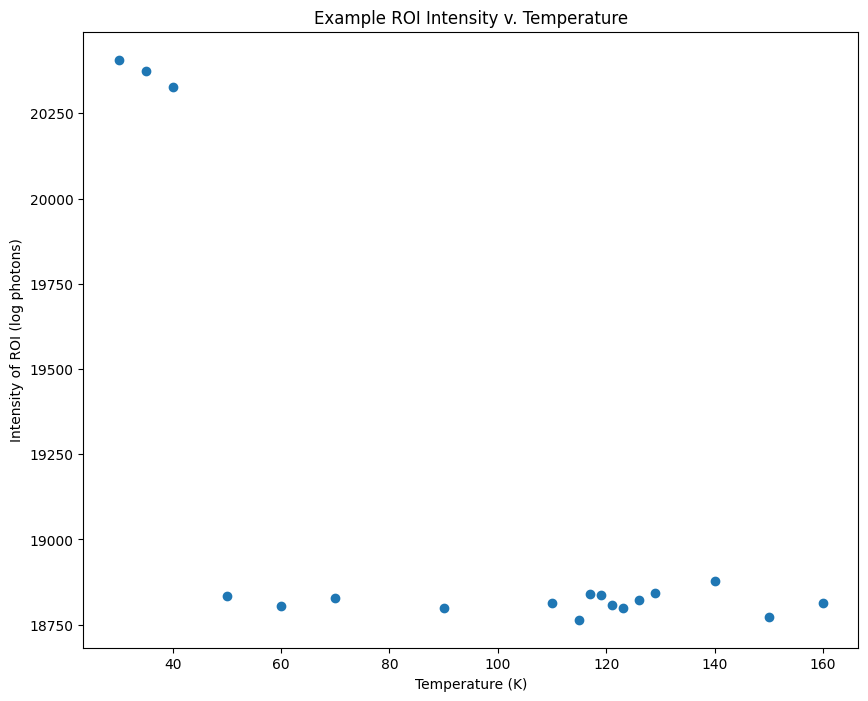

In [11]:
plt.figure(figsize=(10, 8))
temp = [160, 150, 140, 129, 126, 123, 121, 119, 117, 115, 110, 90, 70, 60, 50, 40, 35, 30]
plt.scatter(temp, intensities)
plt.xlabel('Temperature (K)')
plt.ylabel('Intensity of ROI (log photons)')
plt.title('Example ROI Intensity v. Temperature')

output_plot = os.path.join(output_folder, "roi.png")
plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')


Saved standard plot: example7/roi2/log_1.png
Saved standard plot: example7/roi2/log_2.png
Saved standard plot: example7/roi2/log_3.png
Saved standard plot: example7/roi2/log_4.png
Saved standard plot: example7/roi2/log_5.png
Saved standard plot: example7/roi2/log_6.png
Saved standard plot: example7/roi2/log_7.png
Saved standard plot: example7/roi2/log_8.png
Saved standard plot: example7/roi2/log_9.png
Saved standard plot: example7/roi2/log_10.png
Saved standard plot: example7/roi2/log_11.png
Saved standard plot: example7/roi2/log_12.png
Saved standard plot: example7/roi2/log_13.png
Saved standard plot: example7/roi2/log_14.png
Saved standard plot: example7/roi2/log_15.png
Saved standard plot: example7/roi2/log_16.png
Saved standard plot: example7/roi2/log_17.png
Saved standard plot: example7/roi2/log_18.png


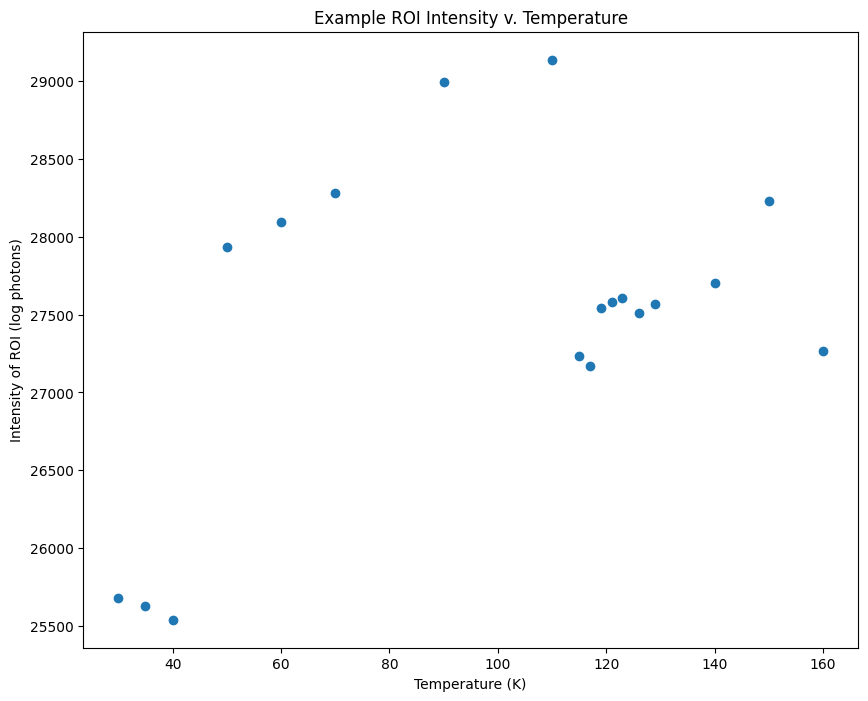

In [12]:
x1, x2, y1, y2 = 950, 1200, 650, 900  # Replace with your actual pixel values
output_folder = "example7/roi2"
intensities2 = []
# 1. Save standard log plots for every folder
for idx, norm_img in enumerate(normalized_images):
    meta = folder_metadata[idx]

    intensities2.append(norm_img[y1:y2, x1:x2].sum())
    
    plt.figure(figsize=(10, 8))
    im = plt.imshow(norm_img, cmap='bwr', origin='lower')
    plt.title(f"{meta['name']},\n{meta['successful_files']} CBF files summed", fontsize=14)
    plt.colorbar(im, label='Normalized Log Intensity')
    plt.xlabel('Detector X (pixels)')
    plt.ylabel('Detector Y (pixels)')
    
    box = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
    plt.gca().add_patch(box)
    
    output_plot = os.path.join(output_folder, f"log_{idx + 1}.png")
    plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Saved standard plot: {output_plot}")

plt.figure(figsize=(10, 8))
temp = [160, 150, 140, 129, 126, 123, 121, 119, 117, 115, 110, 90, 70, 60, 50, 40, 35, 30]
plt.scatter(temp, intensities2)
plt.xlabel('Temperature (K)')
plt.ylabel('Intensity of ROI (log photons)')
plt.title('Example ROI Intensity v. Temperature')

output_plot = os.path.join(output_folder, "roi.png")
plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')

